<a href="https://colab.research.google.com/github/huile09/AI.Palmistry/blob/main/AI_Palmistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Bài tập 5. Nhận diện chỉ tay**

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
import os

Tải dữ liệu

In [ ]:
# Mount drive
drive.mount('/content/drive')

# Giải nén bộ ảnh gốc
!unzip -o -q "/content/drive/MyDrive/palmistry.zip" -d "/content/dataset"


Mounted at /content/drive


Check cây thư mục

In [ ]:
!tree -d /content/dataset

/content/dataset
├── test
│   ├── images
│   └── labels
├── train
│   ├── images
│   └── labels
└── valid
    ├── images
    └── labels

9 directories


Kiểm tra trong thư mục labels

In [ ]:
import os

# Liệt kê thử vài file trong thư mục labels của tập train
label_path = '/content/dataset/train/labels'
files = os.listdir(label_path)

if files:
    with open(os.path.join(label_path, files[0]), 'r') as f:
        print(f"Nội dung file nhãn {files[0]}:\n")
        print(f.read())
else:
    print("Thư mục labels trống không!")

Nội dung file nhãn FIMG_0264_JPG_jpg.rf.1a63e2b050b87af83781686fdc07b025.txt:

0 0.74140625 0.41953125 0.3484375 0.0609375
2 0.5703125 0.38046875 0.23125 0.2890625
3 0.74296875 0.53515625 0.3796875 0.1703125
1 0.5546875 0.5125 0.05625 0.165625


Tạo file cấu hình yaml

In [ ]:
import yaml

data_config = {
    'path': '/content/dataset',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',

    'nc': 4,
    'names': ['Su_Nghiep', 'Sinh_Dao', 'Tri_Dao', 'Tam_Dao']
}

with open('/content/dataset/data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)


Train YOLO

In [ ]:
!pip install ultralytics

In [ ]:
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=32,
    device=0,

    patience=5,
    optimizer='AdamW',
    lr0=0.001,

    degrees=15.0,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, pe

Lưu model

In [ ]:
import shutil
import os

os.makedirs('/content/drive/MyDrive/YOLO_Palmistry', exist_ok=True)

source_path = '/content/runs/detect/train-2/weights/best.pt'
destination_path = '/content/drive/MyDrive/YOLO_Palmistry/model_palm.pt'

if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"Đã lưu model thành công vào Google Drive tại đường dẫn: {destination_path}")
else:
    print("Không tìm thấy file model.")

Test model

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00



Đường chỉ tay nhận diện trên ảnh: Hand_0003287_jpg.rf.543c03dfda4adb955c2d0dad5e22e796.jpg


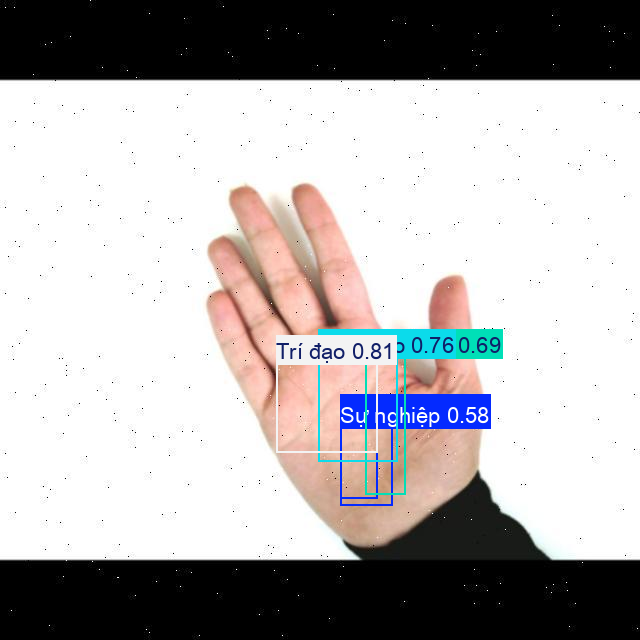


Đường chỉ tay nhận diện trên ảnh: 577_image_palm_jpeg_jpg.rf.fc47fbd83b8fb8add7c58fd1abb90ae8.jpg


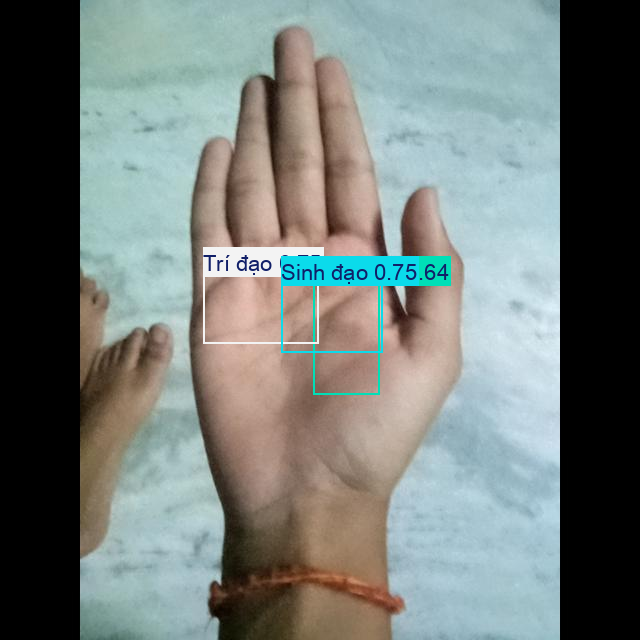


Đường chỉ tay nhận diện trên ảnh: Hand_0005294_jpg.rf.97baccf5566295e849a536a6d6368068.jpg


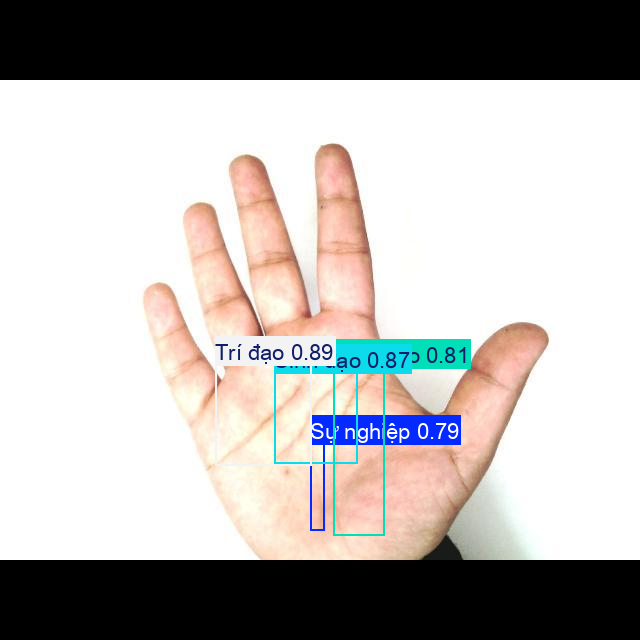

In [ ]:
import os
import random
import cv2
from google.colab.patches import cv2_imshow
from ultralytics import YOLO

drive_model_path = '/content/drive/MyDrive/YOLO_Palmistry/best_palmistry_model.pt'

if os.path.exists(drive_model_path):
    model = YOLO(drive_model_path)

    vietnamese_names = {0: 'Sự nghiệp', 1: 'Sinh đạo', 2: 'Trí đạo', 3: 'Tam đạo'}
    model.model.names = vietnamese_names

    test_image_dir = '/content/dataset/test/images'
    test_images = [os.path.join(test_image_dir, f) for f in os.listdir(test_image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(test_images, min(3, len(test_images)))

    for img_path in sample_images:
        results = model.predict(source=img_path, conf=0.25, imgsz=640, verbose=False)
        annotated_img = results[0].plot()

        print(f"\nĐường chỉ tay nhận diện trên ảnh: {os.path.basename(img_path)}")
        cv2_imshow(annotated_img)
else:
    print("Không tìm thấy file tại đường dẫn")